# Titanic Survival Prediction
Binary classification: predict who survives (1) vs dies (0).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style='whitegrid')

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print('Train shape:', train.shape)
print('Test shape: ', test.shape)
train.head()

Train shape: (891, 12)
Test shape:  (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Exploratory Data Analysis

In [2]:
# Missing values
print('Missing values in train:')
print(train.isnull().sum()[train.isnull().sum() > 0])

Missing values in train:
Age         177
Cabin       687
Embarked      2
dtype: int64


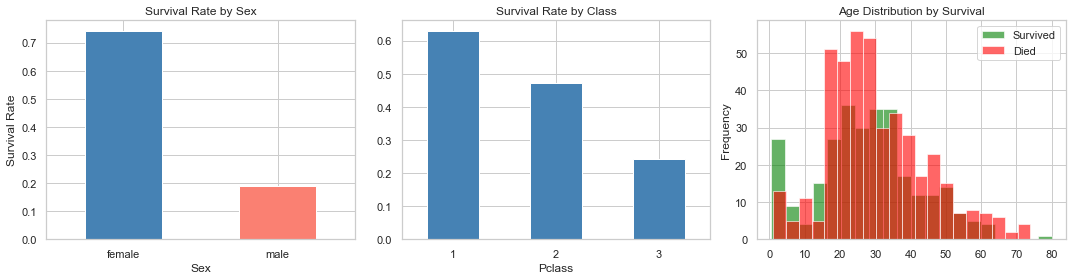

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Survival by sex
train.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[0], color=['steelblue','salmon'])
axes[0].set_title('Survival Rate by Sex')
axes[0].set_ylabel('Survival Rate')
axes[0].tick_params(axis='x', rotation=0)

# Survival by class
train.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Survival Rate by Class')
axes[1].tick_params(axis='x', rotation=0)

# Age distribution
train[train['Survived']==1]['Age'].plot(kind='hist', bins=20, ax=axes[2], alpha=0.6, label='Survived', color='green')
train[train['Survived']==0]['Age'].plot(kind='hist', bins=20, ax=axes[2], alpha=0.6, label='Died', color='red')
axes[2].set_title('Age Distribution by Survival')
axes[2].legend()

plt.tight_layout()
plt.show()

## 2. Feature Engineering

In [4]:
def engineer_features(df):
    df = df.copy()

    # Extract title from Name
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(['Lady','Countess','Capt','Col','Don','Dr',
                                        'Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    # Fill missing Age with median per Title
    df['Age'] = df.groupby('Title')['Age'].transform(lambda x: x.fillna(x.median()))

    # Fill missing Fare and Embarked
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    # Has cabin info?
    df['HasCabin'] = df['Cabin'].notna().astype(int)

    # Family size
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

    # Fare bands
    df['FareBand'] = pd.qcut(df['Fare'], 4, labels=False)

    # Age bands
    df['AgeBand'] = pd.cut(df['Age'], bins=[0,12,18,35,60,100],
                            labels=['Child','Teen','YoungAdult','Adult','Senior'])

    # Encode categoricals
    le = LabelEncoder()
    for col in ['Sex', 'Embarked', 'Title', 'AgeBand']:
        df[col] = le.fit_transform(df[col].astype(str))

    return df

train_fe = engineer_features(train)
test_fe  = engineer_features(test)

FEATURES = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
            'Embarked', 'Title', 'HasCabin', 'FamilySize',
            'IsAlone', 'FareBand', 'AgeBand']

X = train_fe[FEATURES]
y = train_fe['Survived']
X_test_final = test_fe[FEATURES]

print('Features ready. Shape:', X.shape)

Features ready. Shape: (891, 13)


## 3. Train & Evaluate Models

In [5]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    val_acc = accuracy_score(y_val, model.predict(X_val))
    cv_acc  = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()
    print(f'{name:25s}  val_acc={val_acc:.4f}  cv_acc={cv_acc:.4f}')

Logistic Regression        val_acc=0.8045  cv_acc=0.7890


/Users/Bill/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/Bill/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/Bill/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/Bill/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/Bill/Library/Python/3.10/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_s

Random Forest              val_acc=0.8380  cv_acc=0.8103


              precision    recall  f1-score   support

        Died       0.86      0.87      0.86       105
    Survived       0.81      0.80      0.80        74

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



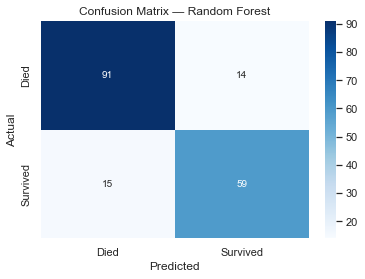

In [6]:
# Detailed evaluation for Random Forest
rf = models['Random Forest']
y_pred = rf.predict(X_val)

print(classification_report(y_val, y_pred, target_names=['Died', 'Survived']))

cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died','Survived'], yticklabels=['Died','Survived'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

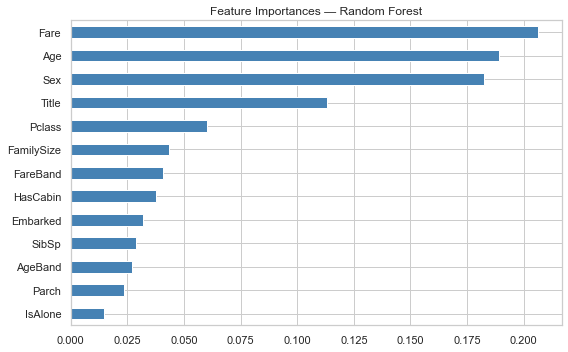

In [7]:
# Feature importance
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
importances.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

## 4. Generate Submission File

In [8]:
# Re-train on full training set and predict test set
rf.fit(X, y)
predictions = rf.predict(X_test_final)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': predictions
})
submission.to_csv('submission.csv', index=False)
print('submission.csv saved!')
submission.head(10)

submission.csv saved!


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0
5,897,0
6,898,0
7,899,0
8,900,1
9,901,0
